In [12]:
# azureml-core of version 1.0.72 or higher is required
import os
import numpy as np
import matplotlib.pyplot as plt
from azureml.core import Workspace, Dataset

# Define Azure ML workspace details
subscription_id = '9ead393f-4604-4166-b88b-9e7f2ca53d62'
resource_group = 'pdsppoc2_rg_data_sandbox_module'
workspace_name = 'pdsppoc2_data_sandbox'

# Connect to the Azure ML workspace
workspace = Workspace(subscription_id, resource_group, workspace_name)

# Get the dataset by name
dataset = Dataset.get_by_name(workspace, name='geofingerprinting')

# Mount the dataset to a local directory
mount_context = dataset.mount(target_path='./mounted_data', overwrite=False)

# Start the mount context
mount_context.start()

print("Dataset mounted at:", mount_context.mount_point)

# Remember to stop the mount context when done
# mount_context.stop()

Dataset mounted at: /tmp/tmpf7iffbdg


In [ ]:
# Path to the 'geofingerprinting' folder
geofingerprinting_path = os.path.join(mount_context.mount_point, "geofingerprinting")

# List all files and directories in the 'geofingerprinting' folder
if os.path.exists(geofingerprinting_path):
    contents = os.listdir(geofingerprinting_path)
    print("Contents of the 'geofingerprinting' folder:")
    for item in contents:
        print(item)
else:
    print("'geofingerprinting' folder does not exist.")

Contents of the 'geofingerprinting' folder:
ground_truth
patches


In [13]:
# Paths to the folders
geofingerprinting_path = f"{ mount_context.mount_point}/geofingerprinting"

ground_truth_path = os.path.join(geofingerprinting_path, "ground_truth")
patches_path = os.path.join(geofingerprinting_path, "patches")

In [ ]:
# Count the number of files in the 'ground_truth_path' folder
if os.path.exists(ground_truth_path):
    num_files = len([f for f in os.listdir(ground_truth_path) if os.path.isfile(os.path.join(ground_truth_path, f))])
    print(f"Number of files in 'ground_truth_path': {num_files}")
else:
    print("'ground_truth_path' folder does not exist.")

Number of files in 'ground_truth_path': 103358


In [ ]:
file_names = [f for f in os.listdir(ground_truth_path) if os.path.isfile(os.path.join(ground_truth_path, f))]
# npy_file_names = [f for f in os.listdir(folder_path) if f.endswith(".npy") and os.path.isfile(os.path.join(folder_path, f))]

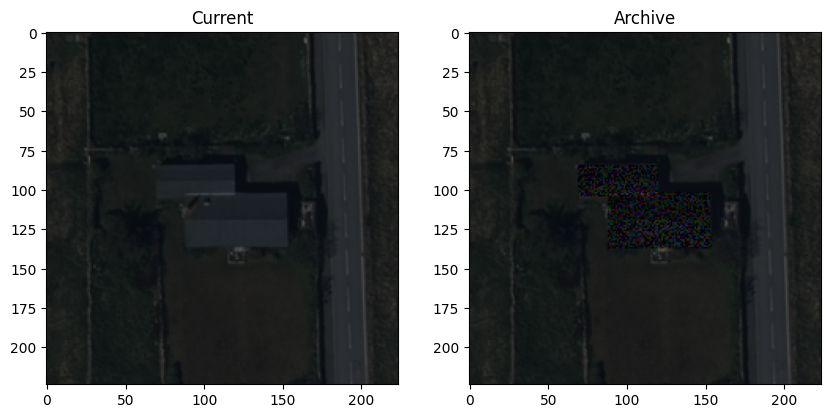

In [16]:
def plot_patch(current, archive):
    # Move channels to the last axis (from (4, 224, 224) to (224, 224, 4))
    current = np.moveaxis(current, 0, -1)
    archive = np.moveaxis(archive, 0, -1)
    
    # Plot the first three channels (RGB)
    fig, ax = plt.subplots(1, 2, figsize=(10, 5))
    ax[0].imshow(np.uint8(current[:, :, :3] / 255))  # Normalize and plot RGB for current
    ax[0].set_title('Current')
    ax[1].imshow(np.uint8(archive[:, :, :3] / 255))  # Normalize and plot RGB for archive
    ax[1].set_title('Archive')
    plt.show()

gt = np.load(os.path.join(ground_truth_path, file_names[3]))
ptch = np.load(os.path.join(patches_path, file_names[3]))

plot_patch(gt, ptch)

In [17]:
print(f'Shape of ground truth: {gt.shape}')
print(f'Shape of patch: {ptch.shape}')

Shape of ground truth: (4, 224, 224)
Shape of patch: (4, 224, 224)
